This will help to learn how to use Seaborn for data visualization in Python. Seaborn is a powerful library built on top of Matplotlib that provides a high-level interface for creating attractive and informative statistical graphics.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


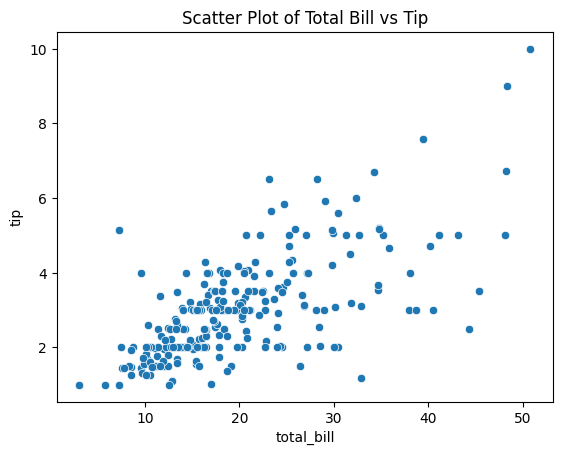

In [12]:
### Scatter Plot
sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.title("Scatter Plot of Total Bill vs Tip")
plt.show()

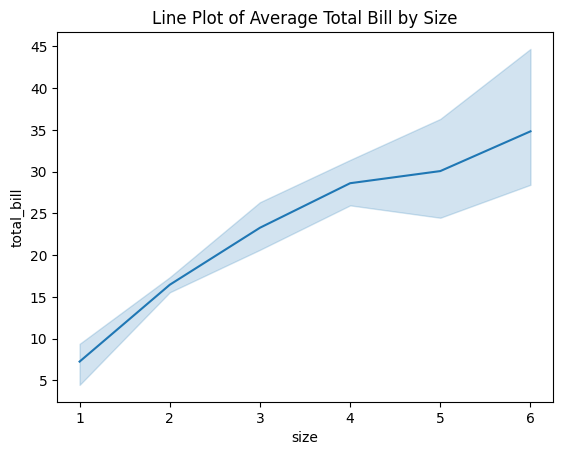

In [13]:
### Line plot
sns.lineplot(x="size",y="total_bill",data=tips,estimator="mean")
plt.title("Line Plot of Average Total Bill by Size")
plt.show()

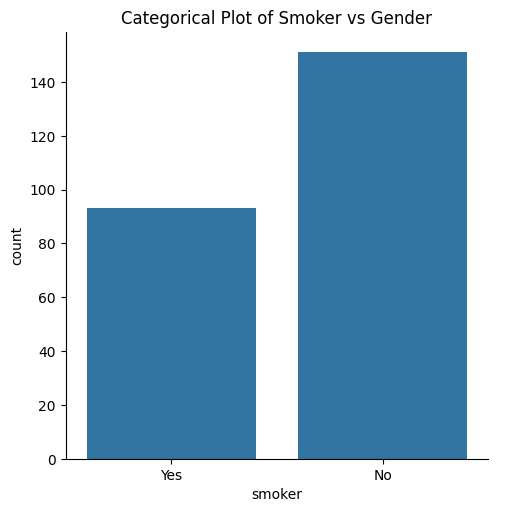

In [ ]:
### Categorical Plot
sns.catplot(x="smoker",data=tips,kind="count")
plt.title("Categorical Plot of Smoker vs Non-Smoker")
plt.show()

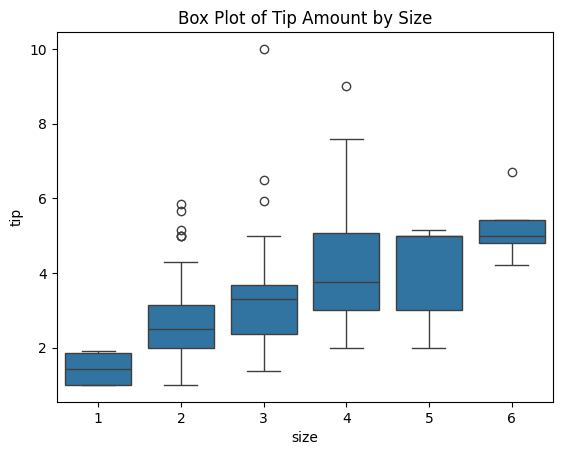

In [ ]:
### box plot showing person paid how much tips
sns.boxplot(x="size",y="tip",data=tips)
plt.title("Box Plot of Tip Amount by Size")
plt.show()

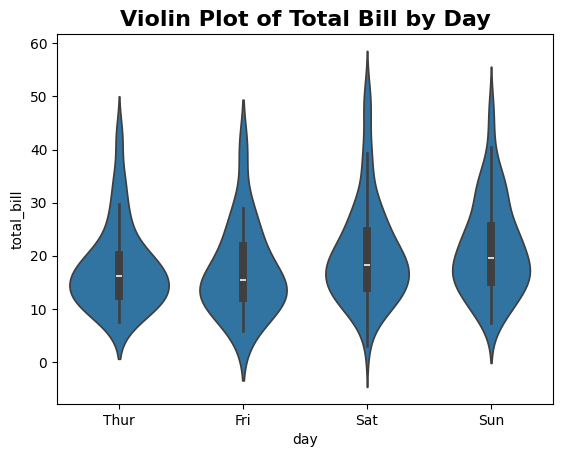

In [18]:
### Violin plot showing day wise distribution of total bill
sns.violinplot(x='day',y='total_bill',data=tips)
plt.title("Violin Plot of Total Bill by Day", fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.show()

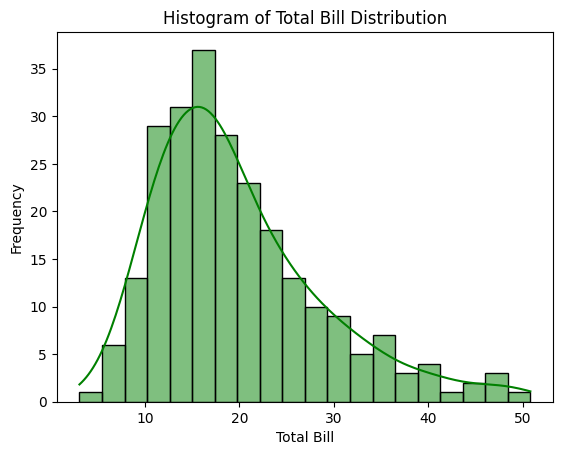

In [24]:
### Histograms showing distribution of total bill
sns.histplot(tips['total_bill'],bins = 20,kde=True,color='green')
plt.title("Histogram of Total Bill Distribution")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.show()

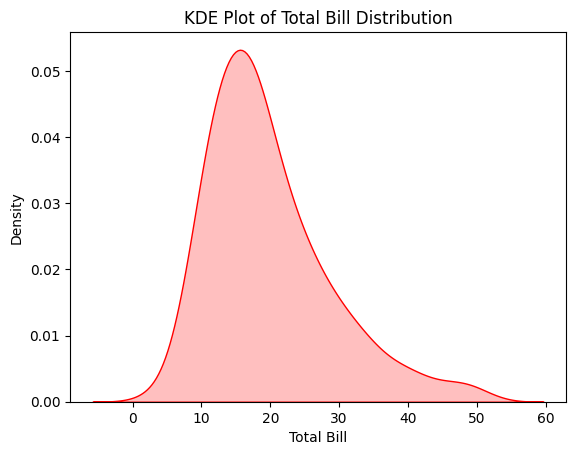

In [23]:
### kde plot showing distribution of total bill
# kde - kernel density estimation
sns.kdeplot(tips['total_bill'],fill=True,color='red')
plt.title("KDE Plot of Total Bill Distribution")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.show()

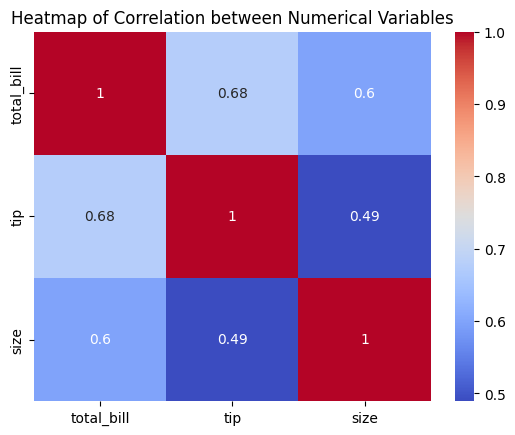

In [27]:
### Heatmap showing correlation between numerical variables
corr = tips[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Heatmap of Correlation between Numerical Variables")
plt.show()

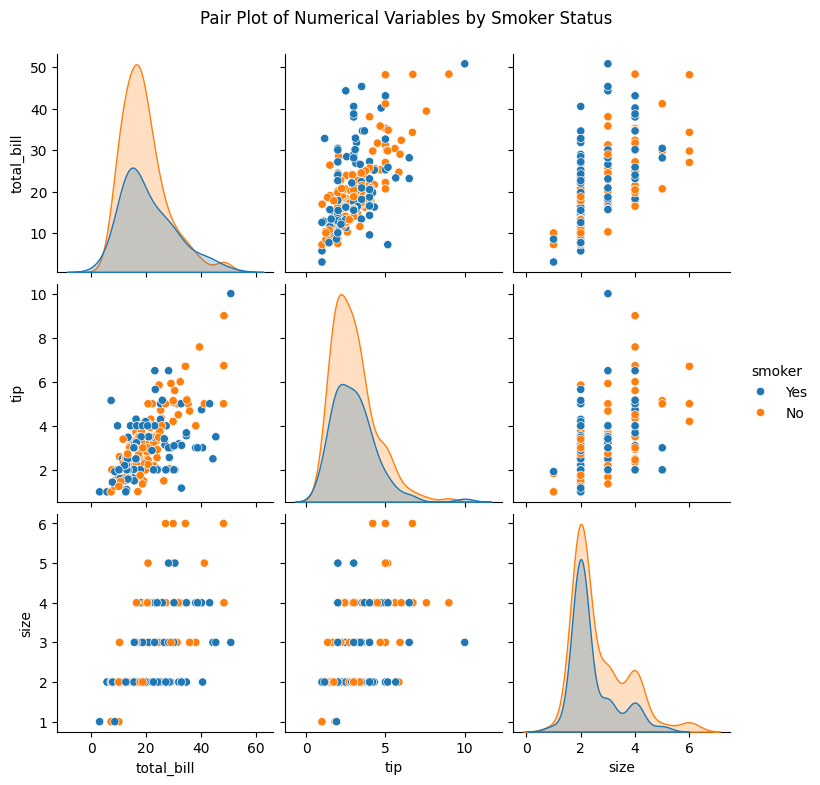

In [37]:
### Pair plot showing pairwise relationships between numerical variables
sns.pairplot(tips,hue='smoker')
# hue - works as filter to differentiate between smoker and non-smoker in the pair plot
plt.suptitle("Pair Plot of Numerical Variables by Smoker Status", y=1.04)
plt.show()

Now using our own data

In [38]:
import pandas  as pd
df = pd.read_csv('sales_data.csv')
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Books,Python Crash Course,1,963.11,963.11,Europe,Debit Card
1,10002,2024-01-02,Electronics,Sony WH-1000XM5,10,54.33,543.30,South America,Debit Card
2,10003,2024-01-03,Books,Atomic Habits,3,1199.50,3598.50,North America,Credit Card
3,10004,2024-01-04,Home Appliances,Philips Air Fryer,2,759.66,1519.32,North America,Credit Card
4,10005,2024-01-05,Clothing,Levi's 501 Jeans,4,532.40,2129.60,South America,UPI


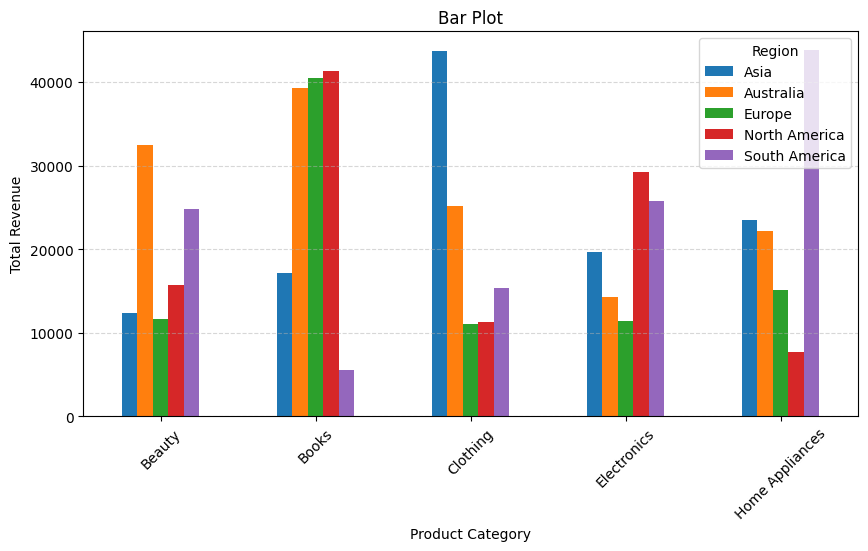

In [ ]:
sales_df = df.groupby(['Product Category','Region']).agg(Total_Revenue=('Total Revenue','sum')).reset_index()
# pivot() reshapes data from long format → wide format.
pivot_df= sales_df.pivot(
    index='Product Category',
    columns='Region',
    values='Total_Revenue'
)
pivot_df.plot(kind='bar', figsize=(10,5))

plt.title("Bar Plot")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Text(0.5, 1.0, 'Pie plot showing distribution of Region and there Revenue')

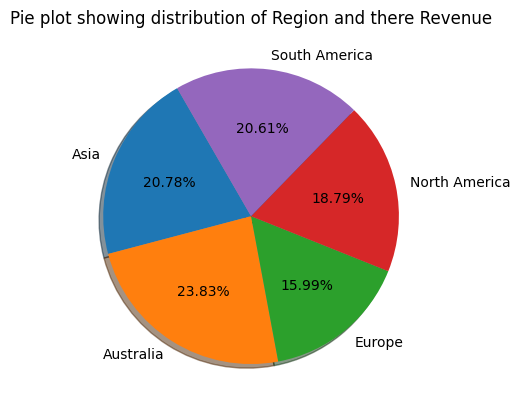

In [50]:
sales_df=df.groupby('Region').agg(Revenue=('Total Revenue','sum')).reset_index()
plt.pie(
    sales_df['Revenue'],labels=sales_df['Region'],autopct='%1.2f%%',shadow=True,startangle=120)
plt.title('Pie plot showing distribution of Region and there Revenue')